In [1]:
import numpy as np
import pandas as pd
import os
import scipy.io as sio
import matplotlib
import matplotlib.pyplot as plt
from numpy.matlib import repmat
from sklearn.preprocessing import normalize
from PIL import Image

In [2]:
data = []

folder = "/home/s2lo/final_project/GIT_folder/data_L"

for filename in os.listdir(folder):
    img_path = os.path.join(folder, filename)
    if os.path.isdir(img_path):
        continue
    if not filename.lower().endswith((".jpg", ".jpeg")):
        continue
        
    img = Image.open(img_path).convert("L")   # make image gray
    data.append(img)

faces_left = np.array(data)
print("Data matrix shape:", faces_left.shape)

Data matrix shape: (100, 1024, 1024)


In [3]:
def viewcolumn(columnvector):
    # viewcolumn(columnvector)
    plt.imshow(columnvector, cmap='gray')
    plt.axis('off')


def normc(Mat):
    # normc(M) normalizes the columns of M to a length of 1
    return normalize(Mat, norm='l2', axis=0)

def viewface(n):
    # to view the nth face (to view 10th, write n=9)
    plt.imshow(faces_left[n], cmap='gray')
    plt.axis('off')

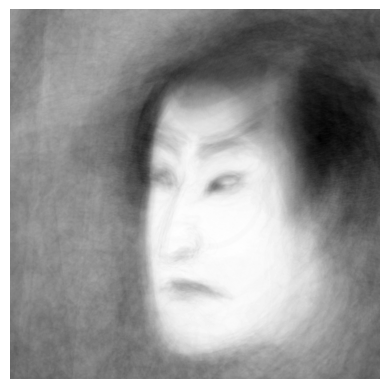

In [4]:
meanface = np.mean(faces_left,axis=0)

viewcolumn(meanface)

In [5]:
data_flat = []


folder = "/home/s2lo/final_project/GIT_folder/data_L"

for filename in os.listdir(folder):
    img_path = os.path.join(folder, filename)
    if os.path.isdir(img_path):
        continue
    if not filename.lower().endswith((".jpg", ".jpeg")):
        continue
        
    img = Image.open(img_path).convert("L")   # make image gray
    arr = np.array(img).flatten(order="C")             # flatten to 1D vector
    data_flat.append(arr)

faces_flat_left = np.array(data_flat)
print("Data matrix shape:", faces_flat_left.shape)

Data matrix shape: (100, 1048576)


In [6]:
def viewcolumnflat(columnvector):
    # viewcolumn(columnvector)
    columnvector = columnvector.reshape(1024,1024)
    plt.imshow(columnvector, cmap='gray')
    plt.axis('off')

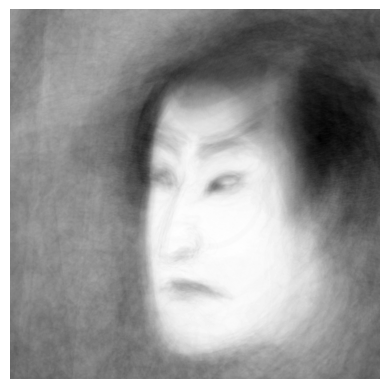

In [7]:
meanface_flat_left = np.mean(faces_flat_left,axis=0, keepdims=True)

viewcolumnflat(meanface_flat_left)

In [8]:
import scipy.sparse as sc

In [9]:
print(faces_flat_left.shape)
faces_flat_left = np.array(data_flat).T
print(faces_flat_left.shape)
print(meanface_flat_left.shape)
meanface_flat_left = np.array(meanface_flat_left).T
print(meanface_flat_left.shape)

(100, 1048576)
(1048576, 100)
(1, 1048576)
(1048576, 1)


In [10]:
A = faces_flat_left - np.matlib.repmat(meanface_flat_left, 1, 100)
eigvals, V = np.linalg.eigh(A.T @ A)
index = np.argsort(-eigvals)
eigvals = eigvals[index]
V = V[:, index]

# choose how many eigenfaces to keep
k = 100
V = V[:, :k]
U = A @ V

In [11]:
U = U.astype(float)
U = normc(U)

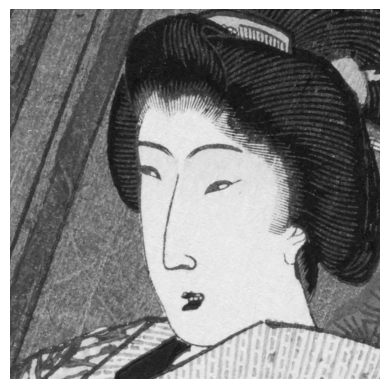

In [12]:
image_path = '/home/s2lo/final_project/faces/gac_32c45258ee.png_0.jpg'
img = Image.open(image_path)
img_gray = img.convert("L")   # make image gray
img_resized = img_gray.resize((1024, 1024))
img_arr = np.array(img_resized)
img_flatten = img_arr.flatten()
face_L = img_flatten.reshape((1048576,1))

plt.imshow(img_arr, cmap='gray')
plt.axis('off')

c = U.T @ (face_L - meanface_flat_left)
Zhat = U @ c + meanface_flat_left

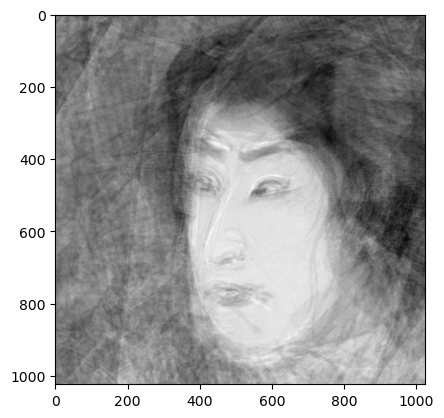

In [13]:
plt.imshow(Zhat.reshape(1024,1024), cmap='gray')

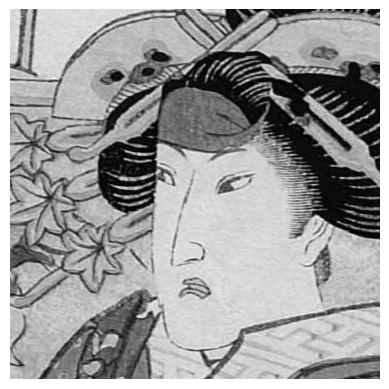

In [14]:
image_path = '/home/s2lo/final_project/faces/ritsumei_Ebi0612(03).jpeg_0.jpg'
img = Image.open(image_path)
img_gray = img.convert("L")   # make image gray
img_resized = img_gray.resize((1024, 1024))
img_arr = np.array(img_resized)
img_flatten = img_arr.flatten()
ritsumei_Ebi = img_flatten.reshape((1048576,1))

plt.imshow(img_arr, cmap='gray')
plt.axis('off')

c = U.T @ (ritsumei_Ebi - meanface_flat_left)
Zhat = U @ c + meanface_flat_left

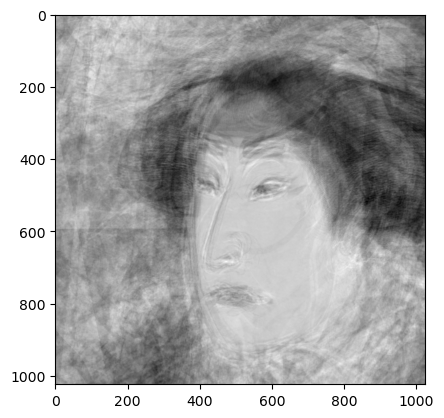

In [15]:
plt.imshow(Zhat.reshape(1024,1024), cmap='gray')

In [16]:
data = []

folder = "/home/s2lo/final_project/GIT_folder/data_R"

for filename in os.listdir(folder):
    img_path = os.path.join(folder, filename)
    if os.path.isdir(img_path):
        continue
    if not filename.lower().endswith((".jpg", ".jpeg")):
        continue
        
    img = Image.open(img_path).convert("L")   # make image gray
    data.append(img)

faces_right = np.array(data)
print("Data matrix shape:", faces_right.shape)

Data matrix shape: (100, 1024, 1024)


In [17]:
def viewcolumn(columnvector):
    # viewcolumn(columnvector)
    plt.imshow(columnvector, cmap='gray')
    plt.axis('off')


def normc(Mat):
    # normc(M) normalizes the columns of M to a length of 1
    return normalize(Mat, norm='l2', axis=0)

def viewface(n):
    # to view the nth face (to view 10th, write n=9)
    plt.imshow(faces_right[n], cmap='gray')
    plt.axis('off')

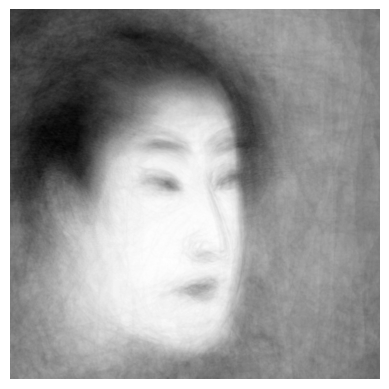

In [18]:
meanface = np.mean(faces_right,axis=0)

viewcolumn(meanface)

In [19]:
data_flat = []


folder = "/home/s2lo/final_project/GIT_folder/data_R"

for filename in os.listdir(folder):
    img_path = os.path.join(folder, filename)
    if os.path.isdir(img_path):
        continue
    if not filename.lower().endswith((".jpg", ".jpeg")):
        continue
        
    img = Image.open(img_path).convert("L")   # make image gray
    arr = np.array(img).flatten(order="C")             # flatten to 1D vector
    data_flat.append(arr)

faces_flat_right = np.array(data_flat)
print("Data matrix shape:", faces_flat_right.shape)

Data matrix shape: (100, 1048576)


In [20]:
def viewcolumnflat(columnvector):
    # viewcolumn(columnvector)
    columnvector = columnvector.reshape(1024,1024)
    plt.imshow(columnvector, cmap='gray')
    plt.axis('off')

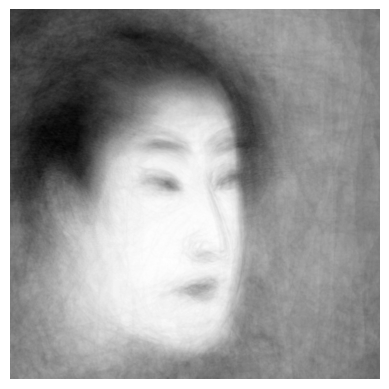

In [21]:
meanface_flat_right = np.mean(faces_flat_right,axis=0, keepdims=True)

viewcolumnflat(meanface_flat_right)

In [22]:
print(faces_flat_right.shape)
faces_flat_right = np.array(data_flat).T
print(faces_flat_right.shape)
print(meanface_flat_right.shape)
meanface_flat_right = np.array(meanface_flat_right).T
print(meanface_flat_right.shape)

(100, 1048576)
(1048576, 100)
(1, 1048576)
(1048576, 1)


In [23]:
A = faces_flat_right - np.matlib.repmat(meanface_flat_right, 1, 100)
eigvals, V = np.linalg.eigh(A.T @ A)
index = np.argsort(-eigvals)
eigvals = eigvals[index]
V = V[:, index]

# choose how many eigenfaces to keep
k = 100
V = V[:, :k]
U = A @ V

In [24]:
U = U.astype(float)
U = normc(U)

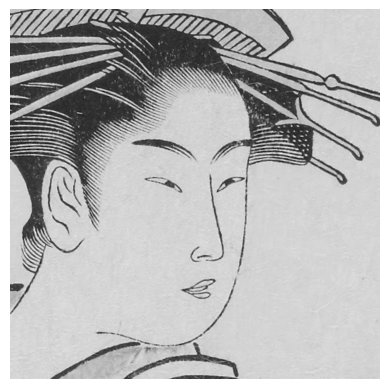

In [25]:
image_path = '/home/s2lo/final_project/faces/gac_30c597d422.png_1.jpg'
img = Image.open(image_path)
img_gray = img.convert("L")   # make image gray
img_resized = img_gray.resize((1024, 1024))
img_arr = np.array(img_resized)
img_flatten = img_arr.flatten()
face_L = img_flatten.reshape((1048576,1))

plt.imshow(img_arr, cmap='gray')
plt.axis('off')

c = U.T @ (face_L - meanface_flat_right)
Zhat = U @ c + meanface_flat_right

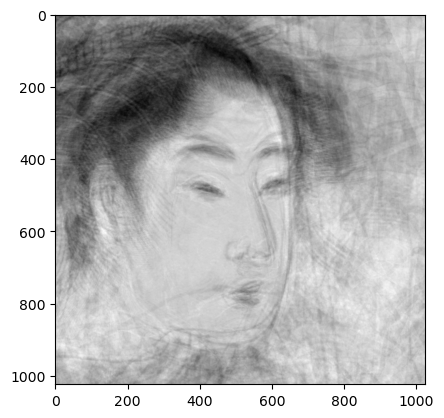

In [26]:
plt.imshow(Zhat.reshape(1024,1024), cmap='gray')

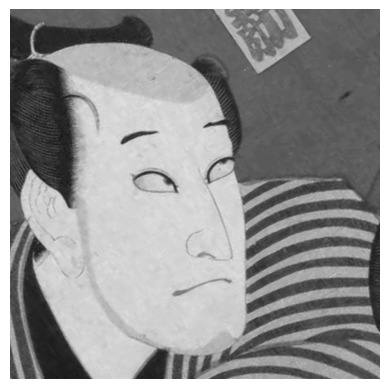

In [27]:
image_path = '/home/s2lo/final_project/faces/ritsumei_tokUY003.jpeg_0.jpg'
img = Image.open(image_path)
img_gray = img.convert("L")   # make image gray
img_resized = img_gray.resize((1024, 1024))
img_arr = np.array(img_resized)
img_flatten = img_arr.flatten()
ritsumei = img_flatten.reshape((1048576,1))

plt.imshow(img_arr, cmap='gray')
plt.axis('off')

c = U.T @ (ritsumei - meanface_flat_right)
Zhat = U @ c + meanface_flat_right

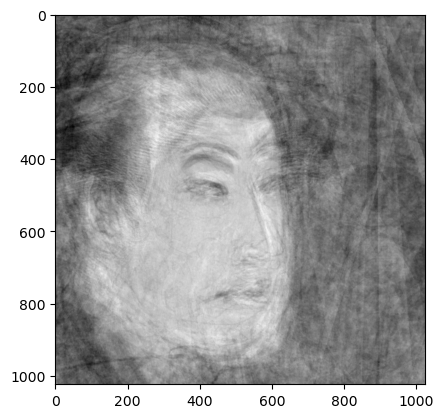

In [28]:
plt.imshow(Zhat.reshape(1024,1024), cmap='gray')